# Data Understanding - ECGFiveDays Dataset
## *Tujuan Notebook:*
- Memahami struktur dan karakteristik dataset ECGFiveDays
- Melakukan exploratory data analysis (EDA) komprehensif
- Mengidentifikasi insight untuk tahap preprocessing
- Mendeteksi potensi masalah (noise, outliers, imbalance)
 
Dataset: ECGFiveDays dari UCR Time Series Classification Archive



### 1. Setup & Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


Library yang digunakan:

- NumPy & Pandas: Manipulasi data numerik dan tabular
- Matplotlib & Seaborn: Visualisasi data
- Pathlib: Path management yang cross-platform
- Warnings: Suppress warning messages untuk output yang bersih

### 2. Define Helper Functions
Tujuan: Membuat fungsi reusable untuk loading dataset UCR format

In [6]:
def load_ucr_dataset(filepath):
    """
    Load UCR time series dataset from txt/arff/ts file.
    
    Parameters:
    -----------
    filepath : str or Path
        Path to the dataset file
    
    Returns:
    --------
    X : numpy array
        Time series data (n_samples, n_timepoints)
    y : numpy array
        Labels (n_samples,)
    """
    filepath = Path(filepath)
    
    if filepath.suffix == '.txt':
        # UCR .txt format: first column is label, rest are time series values
        data = np.loadtxt(filepath)
        y = data[:, 0].astype(int)
        X = data[:, 1:]
    
    elif filepath.suffix == '.arff':
        # ARFF format - parse manually
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        # Find @data section
        data_start = None
        for i, line in enumerate(lines):
            if line.strip().lower() == '@data':
                data_start = i + 1
                break
        
        if data_start is None:
            raise ValueError("Could not find @data section in ARFF file")
        
        # Parse data
        data_lines = [line.strip() for line in lines[data_start:] if line.strip()]
        data = []
        for line in data_lines:
            values = line.split(',')
            data.append([float(v) for v in values])
        
        data = np.array(data)
        y = data[:, -1].astype(int)  # Last column is label in ARFF
        X = data[:, :-1]
    
    elif filepath.suffix == '.ts':
        # TS format - sktime format
        # Simple implementation for univariate series
        data = []
        labels = []
        with open(filepath, 'r') as f:
            for line in f:
                if line.strip() and not line.startswith('@'):
                    parts = line.strip().split(':')
                    if len(parts) >= 2:
                        label = parts[0]
                        series = [float(x) for x in parts[1].split(',') if x.strip()]
                        data.append(series)
                        labels.append(label)
        
        X = np.array(data)
        y = np.array(labels).astype(int)
    
    else:
        raise ValueError(f"Unsupported file format: {filepath.suffix}")
    
    return X, y

print("✓ Helper functions defined")


✓ Helper functions defined


Fungsi utama: load_ucr_dataset(filepath)
Fungsi ini mendukung 3 format file UCR:

- .txt format: Label di kolom pertama, values di kolom sisanya
- .arff format: Weka ARFF dengan section @data
- .ts format: sktime format untuk time series

Return:

- X: numpy array dengan shape (n_samples, n_timepoints)
- y: numpy array dengan shape (n_samples,) berisi label

Keunggulan:

- Robust terhadap berbagai format
- Error handling yang jelas
- Consistent output format



### 3. Load Dataset
##### Define dataset paths

In [7]:
DATA_DIR = Path('ECGFiveDays')
TRAIN_FILE = DATA_DIR / 'ECGFiveDays_TRAIN.txt'
TEST_FILE = DATA_DIR / 'ECGFiveDays_TEST.txt'

# Check if files exist
if not TRAIN_FILE.exists():
    raise FileNotFoundError(f"Train file not found: {TRAIN_FILE}")
if not TEST_FILE.exists():
    raise FileNotFoundError(f"Test file not found: {TEST_FILE}")

print(f"✓ Dataset directory found: {DATA_DIR}")
print(f"✓ Train file: {TRAIN_FILE.name}")
print(f"✓ Test file: {TEST_FILE.name}")

✓ Dataset directory found: ECGFiveDays
✓ Train file: ECGFiveDays_TRAIN.txt
✓ Test file: ECGFiveDays_TEST.txt


##### Load train and test data

In [8]:
X_train, y_train = load_ucr_dataset(TRAIN_FILE)
X_test, y_test = load_ucr_dataset(TEST_FILE)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape:  {X_test.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Test labels shape:  {y_test.shape}")

DATASET LOADED SUCCESSFULLY
Train set shape: (23, 136)
Test set shape:  (861, 136)
Train labels shape: (23,)
Test labels shape:  (861,)


### 4. Basic Dataset Information
Tujuan: Mendapatkan overview high-level tentang dataset.
##### Create summary dataframe

In [9]:
summary_data = {
    'Metric': [
        'Number of training samples',
        'Number of test samples',
        'Total samples',
        'Time series length',
        'Number of classes',
        'Train/Test ratio'
    ],
    'Value': [
        X_train.shape[0],
        X_test.shape[0],
        X_train.shape[0] + X_test.shape[0],
        X_train.shape[1],
        len(np.unique(y_train)),
        f"{X_train.shape[0]}/{X_test.shape[0]} ({X_train.shape[0]/X_test.shape[0]:.3f})"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))


DATASET SUMMARY
                    Metric          Value
Number of training samples             23
    Number of test samples            861
             Total samples            884
        Time series length            136
         Number of classes              2
          Train/Test ratio 23/861 (0.027)


##### Check unique classes

In [10]:
unique_train = np.unique(y_train)
unique_test = np.unique(y_test)

print("\n" + "=" * 60)
print("CLASS INFORMATION")
print("=" * 60)
print(f"Unique classes in train: {unique_train}")
print(f"Unique classes in test:  {unique_test}")
print(f"Class consistency: {'✓ PASS' if np.array_equal(unique_train, unique_test) else '✗ FAIL'}")


CLASS INFORMATION
Unique classes in train: [1 2]
Unique classes in test:  [1 2]
Class consistency: ✓ PASS


### 5. Class Distribution Analysis
Tujuan: Mendapatkan overview high-level tentang dataset.
##### Calculate class distribution

In [11]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

distribution_df = pd.DataFrame({
    'Class': train_counts.index,
    'Train Count': train_counts.values,
    'Train %': (train_counts.values / len(y_train) * 100).round(2),
    'Test Count': test_counts.values,
    'Test %': (test_counts.values / len(y_test) * 100).round(2)
})

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
print(distribution_df.to_string(index=False))


CLASS DISTRIBUTION
 Class  Train Count  Train %  Test Count  Test %
     1           14    60.87         428   49.71
     2            9    39.13         433   50.29


##### Visualize class distribution

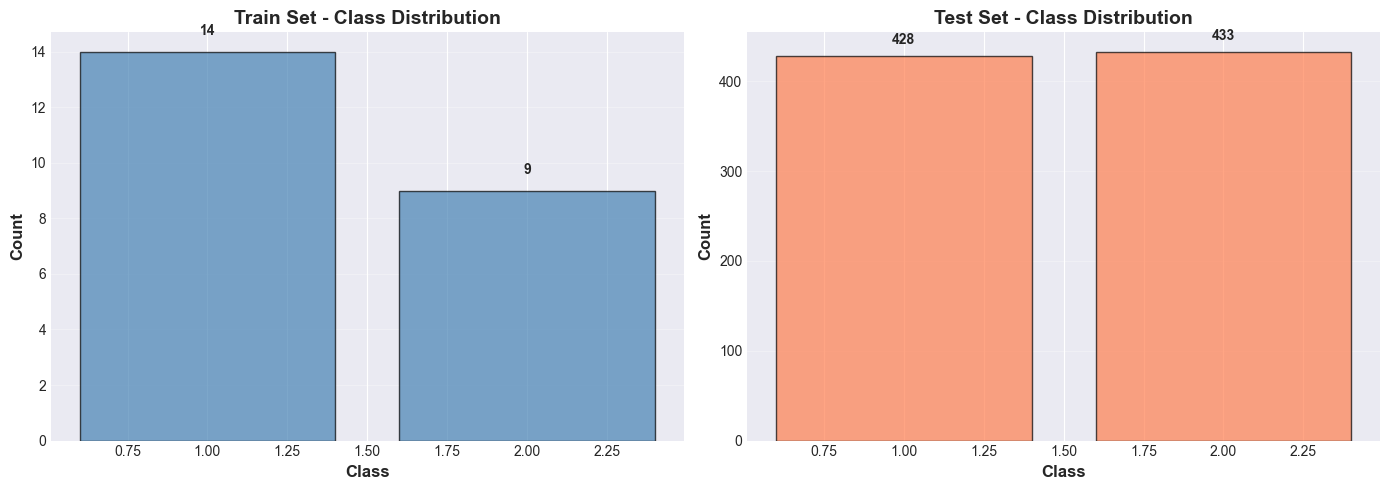


Imbalance Ratio (Train): 1.56
Imbalance Ratio (Test):  1.01
Balance Status: ⚠ Imbalanced


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Train distribution
axes[0].bar(train_counts.index, train_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Train Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_counts.values):
    axes[0].text(train_counts.index[i], v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# Test distribution
axes[1].bar(test_counts.index, test_counts.values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].set_title('Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_counts.values):
    axes[1].text(test_counts.index[i], v + 10, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Check balance
imbalance_ratio_train = train_counts.max() / train_counts.min()
imbalance_ratio_test = test_counts.max() / test_counts.min()

print(f"\nImbalance Ratio (Train): {imbalance_ratio_train:.2f}")
print(f"Imbalance Ratio (Test):  {imbalance_ratio_test:.2f}")
print(f"Balance Status: {'✓ Balanced' if imbalance_ratio_train < 1.5 else '⚠ Imbalanced'}")


Analisis yang dilakukan:

- Hitung distribusi absolute - berapa sample per kelas
- Hitung distribusi relatif (%) - persentase per kelas
- Visualisasi bar chart - perbandingan visual
- Hitung imbalance ratio - max_count / min_count

### 6. Data Quality Check
Tujuan: Memastikan data dalam kondisi baik untuk modeling.
##### Check for missing values

In [12]:
train_missing = np.isnan(X_train).sum()
test_missing = np.isnan(X_test).sum()

print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)
print(f"Missing values in train: {train_missing}")
print(f"Missing values in test:  {test_missing}")
print(f"Missing values status: {'✓ PASS - No missing values' if train_missing == 0 and test_missing == 0 else '✗ FAIL - Contains missing values'}")


DATA QUALITY CHECK
Missing values in train: 0
Missing values in test:  0
Missing values status: ✓ PASS - No missing values


##### Check for infinite values

In [13]:
train_inf = np.isinf(X_train).sum()
test_inf = np.isinf(X_test).sum()

print(f"\nInfinite values in train: {train_inf}")
print(f"Infinite values in test:  {test_inf}")
print(f"Infinite values status: {'✓ PASS - No infinite values' if train_inf == 0 and test_inf == 0 else '✗ FAIL - Contains infinite values'}")



Infinite values in train: 0
Infinite values in test:  0
Infinite values status: ✓ PASS - No infinite values


##### Check data types and value ranges

In [14]:
print(f"\nData type (train): {X_train.dtype}")
print(f"Data type (test):  {X_test.dtype}")

print(f"\nValue range (train): [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"Value range (test):  [{X_test.min():.4f}, {X_test.max():.4f}]")



Data type (train): float64
Data type (test):  float64

Value range (train): [-6.5112, 5.4211]
Value range (test):  [-7.1078, 6.0328]


### 7. Statistical Summary
##### Calculate statistics per dataset

In [15]:
stats_train = {
    'Mean': np.mean(X_train),
    'Median': np.median(X_train),
    'Std Dev': np.std(X_train),
    'Min': np.min(X_train),
    'Max': np.max(X_train),
    'Q25': np.percentile(X_train, 25),
    'Q75': np.percentile(X_train, 75)
}

stats_test = {
    'Mean': np.mean(X_test),
    'Median': np.median(X_test),
    'Std Dev': np.std(X_test),
    'Min': np.min(X_test),
    'Max': np.max(X_test),
    'Q25': np.percentile(X_test, 25),
    'Q75': np.percentile(X_test, 75)
}

stats_df = pd.DataFrame({
    'Statistic': stats_train.keys(),
    'Train': [f"{v:.4f}" for v in stats_train.values()],
    'Test': [f"{v:.4f}" for v in stats_test.values()]
})

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY (ALL DATA)")
print("=" * 60)
print(stats_df.to_string(index=False))


STATISTICAL SUMMARY (ALL DATA)
Statistic   Train    Test
     Mean  0.0000  0.0000
   Median -0.0339 -0.0266
  Std Dev  0.9963  0.9963
      Min -6.5112 -7.1078
      Max  5.4211  6.0328
      Q25 -0.2030 -0.1799
      Q75  0.1835  0.1698


### 8. Visualize Random Samples

##### Plot random samples from each class

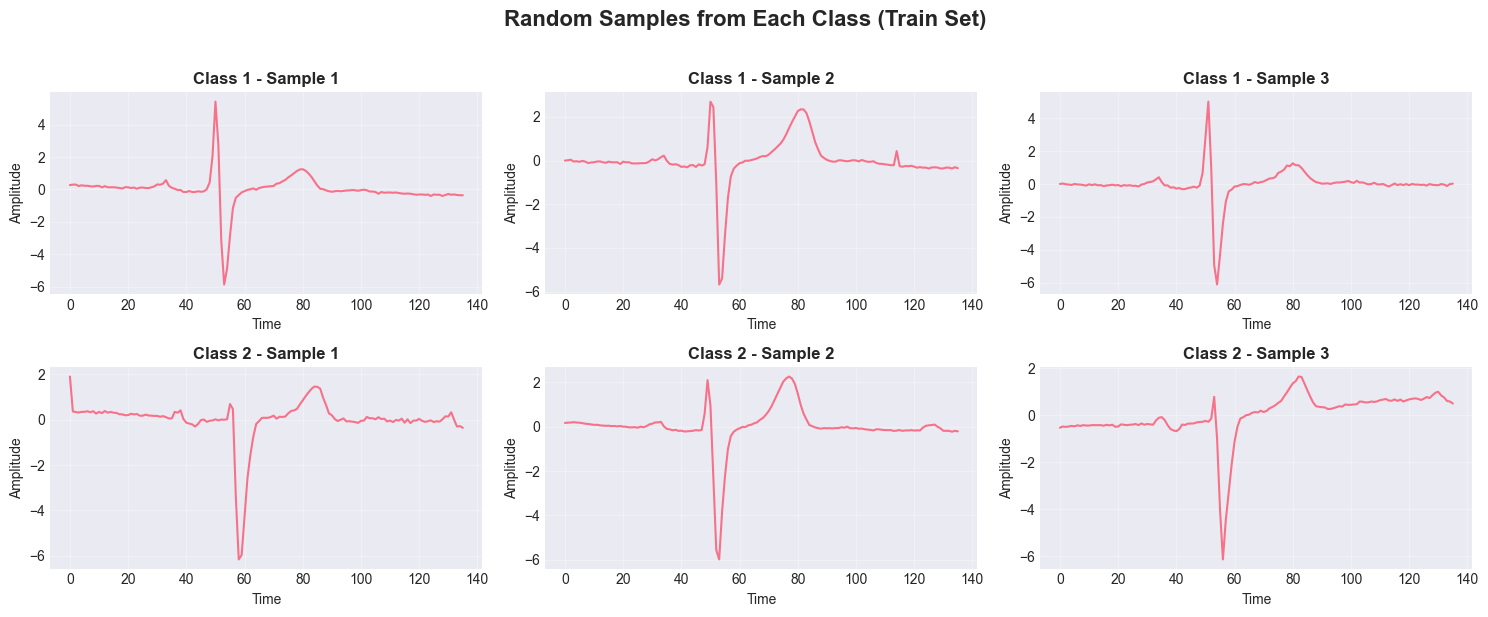

In [16]:
n_samples = 3
classes = np.unique(y_train)

fig, axes = plt.subplots(len(classes), n_samples, figsize=(15, 6))

for i, cls in enumerate(classes):
    # Get indices for this class
    indices = np.where(y_train == cls)[0]
    random_indices = np.random.choice(indices, size=min(n_samples, len(indices)), replace=False)
    
    for j, idx in enumerate(random_indices):
        ax = axes[i, j] if len(classes) > 1 else axes[j]
        ax.plot(X_train[idx], linewidth=1.5)
        ax.set_title(f'Class {cls} - Sample {j+1}', fontweight='bold')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)

plt.suptitle('Random Samples from Each Class (Train Set)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9. Average Signal per Class
##### Calculate mean and std for each class

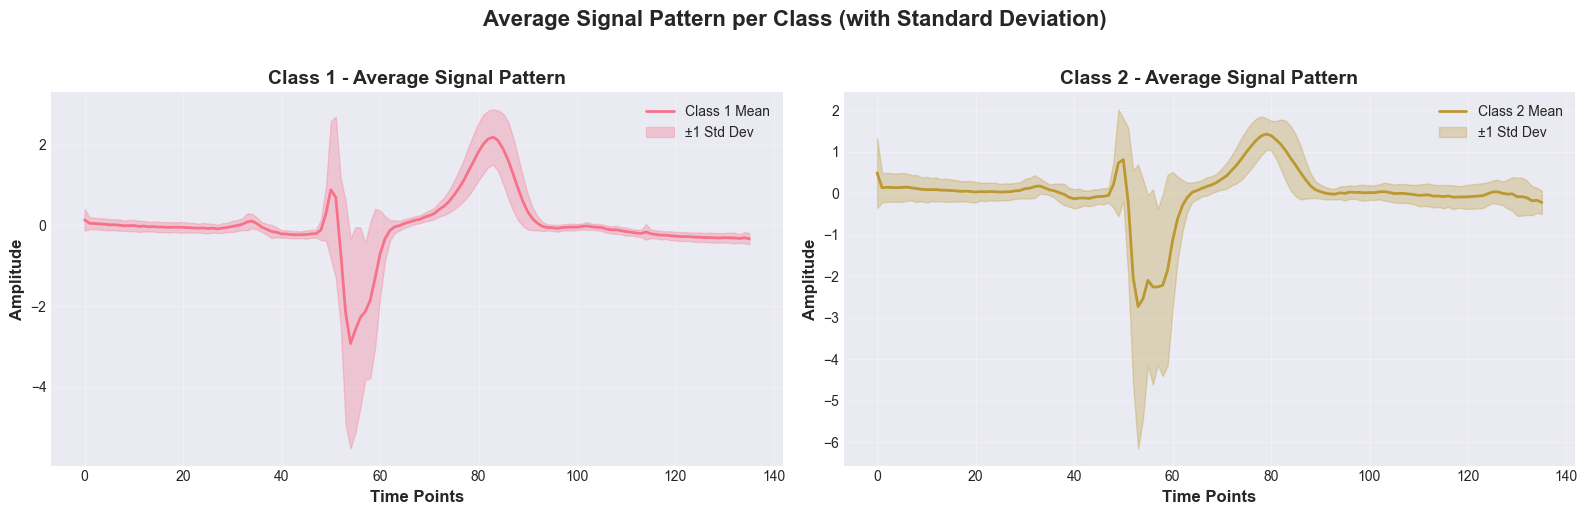

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, cls in enumerate(classes):
    # Get all samples for this class
    class_samples = X_train[y_train == cls]
    
    # Calculate mean and std
    mean_signal = np.mean(class_samples, axis=0)
    std_signal = np.std(class_samples, axis=0)
    
    # Plot on separate subplot
    ax = axes[i]
    time_points = np.arange(len(mean_signal))
    
    ax.plot(time_points, mean_signal, linewidth=2, label=f'Class {cls} Mean', color=f'C{i}')
    ax.fill_between(time_points, 
                     mean_signal - std_signal, 
                     mean_signal + std_signal, 
                     alpha=0.3, 
                     color=f'C{i}',
                     label=f'±1 Std Dev')
    
    ax.set_xlabel('Time Points', fontsize=12, fontweight='bold')
    ax.set_ylabel('Amplitude', fontsize=12, fontweight='bold')
    ax.set_title(f'Class {cls} - Average Signal Pattern', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Average Signal Pattern per Class (with Standard Deviation)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Overlay comparison of mean signals

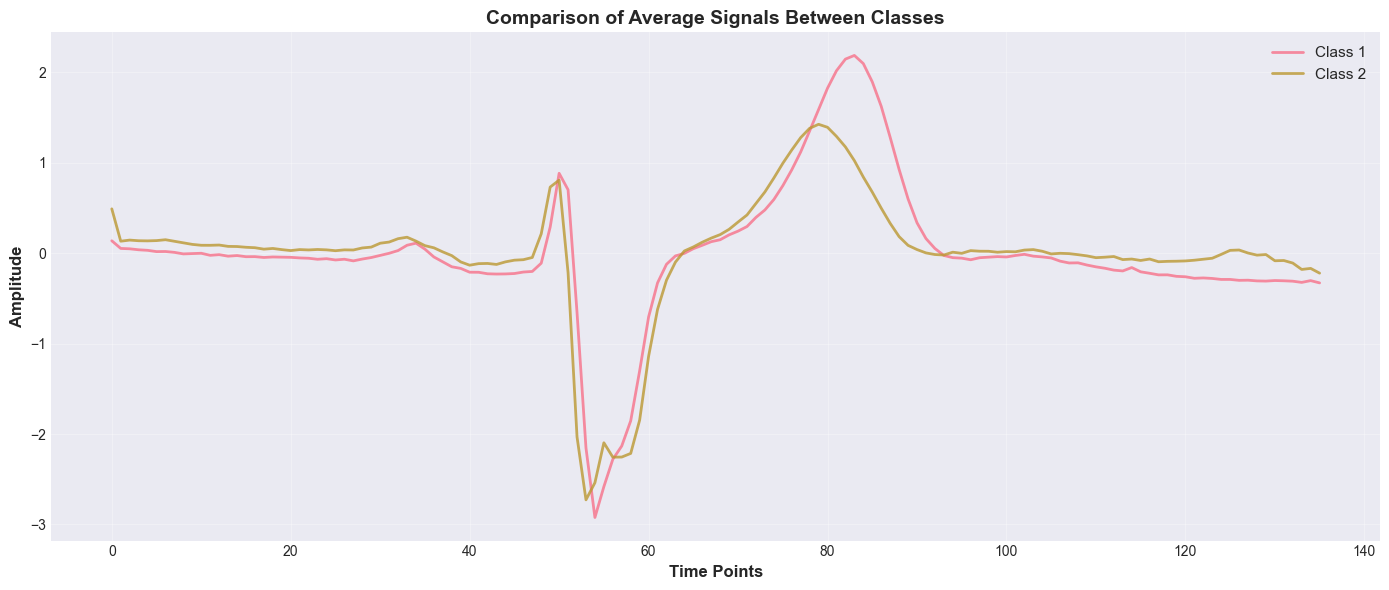


💡 Insight: Perhatikan perbedaan pola antar kelas untuk memahami separability


In [18]:
plt.figure(figsize=(14, 6))

for cls in classes:
    class_samples = X_train[y_train == cls]
    mean_signal = np.mean(class_samples, axis=0)
    plt.plot(mean_signal, linewidth=2, label=f'Class {cls}', alpha=0.8)

plt.xlabel('Time Points', fontsize=12, fontweight='bold')
plt.ylabel('Amplitude', fontsize=12, fontweight='bold')
plt.title('Comparison of Average Signals Between Classes', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Insight: Perhatikan perbedaan pola antar kelas untuk memahami separability")

### 10. Statistical Analysis per Class
##### Calculate statistics per class

In [19]:
class_stats = []

for cls in classes:
    class_data = X_train[y_train == cls]
    
    stats = {
        'Class': cls,
        'N Samples': len(class_data),
        'Mean': np.mean(class_data),
        'Std': np.std(class_data),
        'Min': np.min(class_data),
        'Max': np.max(class_data),
        'Median': np.median(class_data)
    }
    class_stats.append(stats)

class_stats_df = pd.DataFrame(class_stats)
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY PER CLASS")
print("=" * 60)
print(class_stats_df.to_string(index=False))


STATISTICAL SUMMARY PER CLASS
 Class  N Samples          Mean      Std       Min      Max    Median
     1         14 -1.225788e-10 0.996317 -6.119792 5.421075 -0.067392
     2          9  2.906863e-10 0.996317 -6.511159 3.806948  0.023753


### 11. Distribution Analysis - Box Plots

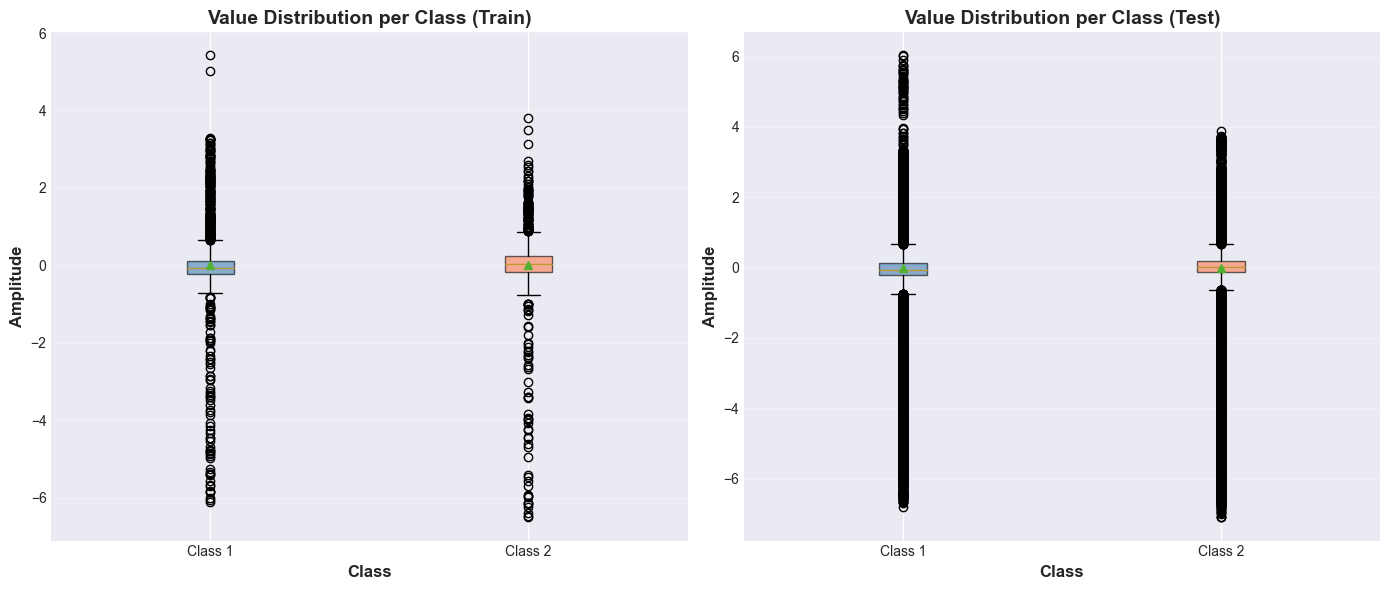

In [20]:
# Create box plots for value distribution per class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data for box plots
data_by_class_train = [X_train[y_train == cls].flatten() for cls in classes]
data_by_class_test = [X_test[y_test == cls].flatten() for cls in classes]

# Train set box plot
bp1 = axes[0].boxplot(data_by_class_train, labels=[f'Class {cls}' for cls in classes],
                       patch_artist=True, showmeans=True)
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude', fontsize=12, fontweight='bold')
axes[0].set_title('Value Distribution per Class (Train)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Color the boxes
colors = ['steelblue', 'coral']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Test set box plot
bp2 = axes[1].boxplot(data_by_class_test, labels=[f'Class {cls}' for cls in classes],
                       patch_artist=True, showmeans=True)
axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude', fontsize=12, fontweight='bold')
axes[1].set_title('Value Distribution per Class (Test)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.tight_layout()
plt.show()


### 12. Signal Variance Analysis

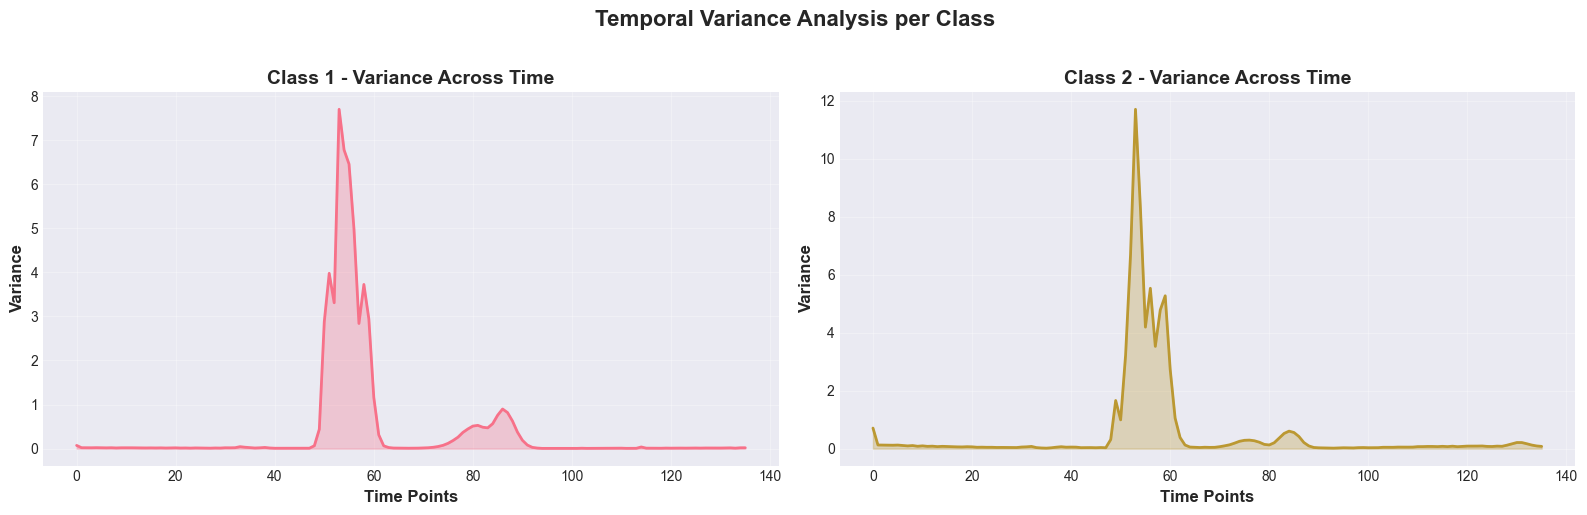


💡 Insight: Time points dengan variance tinggi mungkin lebih informatif untuk klasifikasi


In [21]:
# Calculate variance per time point for each class
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, cls in enumerate(classes):
    class_samples = X_train[y_train == cls]
    variance_per_timepoint = np.var(class_samples, axis=0)
    
    ax = axes[i]
    ax.plot(variance_per_timepoint, linewidth=2, color=f'C{i}')
    ax.fill_between(range(len(variance_per_timepoint)), variance_per_timepoint, 
                     alpha=0.3, color=f'C{i}')
    ax.set_xlabel('Time Points', fontsize=12, fontweight='bold')
    ax.set_ylabel('Variance', fontsize=12, fontweight='bold')
    ax.set_title(f'Class {cls} - Variance Across Time', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Temporal Variance Analysis per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Insight: Time points dengan variance tinggi mungkin lebih informatif untuk klasifikasi")

### 13. Outlier Detection

In [22]:
# Detect potential outliers using IQR method
def detect_outliers_iqr(data, multiplier=1.5):
    """Detect outliers using IQR method"""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr
    
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

# Check for outliers in train set
outliers_train, lb_train, ub_train = detect_outliers_iqr(X_train.flatten())
n_outliers_train = np.sum(outliers_train)
pct_outliers_train = (n_outliers_train / X_train.size) * 100

print("=" * 60)
print("OUTLIER ANALYSIS (IQR Method, multiplier=1.5)")
print("=" * 60)
print(f"Train set:")
print(f"  - Total values: {X_train.size}")
print(f"  - Outliers detected: {n_outliers_train} ({pct_outliers_train:.2f}%)")
print(f"  - Lower bound: {lb_train:.4f}")
print(f"  - Upper bound: {ub_train:.4f}")

# Check per class
print("\nOutliers per class (Train):")
for cls in classes:
    class_data = X_train[y_train == cls]
    outliers_cls, _, _ = detect_outliers_iqr(class_data.flatten())
    n_outliers_cls = np.sum(outliers_cls)
    pct_outliers_cls = (n_outliers_cls / class_data.size) * 100
    print(f"  Class {cls}: {n_outliers_cls} outliers ({pct_outliers_cls:.2f}%)")


OUTLIER ANALYSIS (IQR Method, multiplier=1.5)
Train set:
  - Total values: 3128
  - Outliers detected: 437 (13.97%)
  - Lower bound: -0.7827
  - Upper bound: 0.7633

Outliers per class (Train):
  Class 1: 291 outliers (15.28%)
  Class 2: 152 outliers (12.42%)


### 14. Signal Length Consistency Check

In [23]:
# Verify all signals have same length
train_lengths = [len(signal) for signal in X_train]
test_lengths = [len(signal) for signal in X_test]

unique_train_lengths = np.unique(train_lengths)
unique_test_lengths = np.unique(test_lengths)

print("=" * 60)
print("SIGNAL LENGTH CONSISTENCY")
print("=" * 60)
print(f"Train - Unique lengths: {unique_train_lengths}")
print(f"Test - Unique lengths:  {unique_test_lengths}")
print(f"Length consistency: {'✓ PASS - All signals have same length' if len(unique_train_lengths) == 1 and len(unique_test_lengths) == 1 else '✗ FAIL - Variable length signals detected'}")

SIGNAL LENGTH CONSISTENCY
Train - Unique lengths: [136]
Test - Unique lengths:  [136]
Length consistency: ✓ PASS - All signals have same length


### 15. Class Separability - Visual Inspection

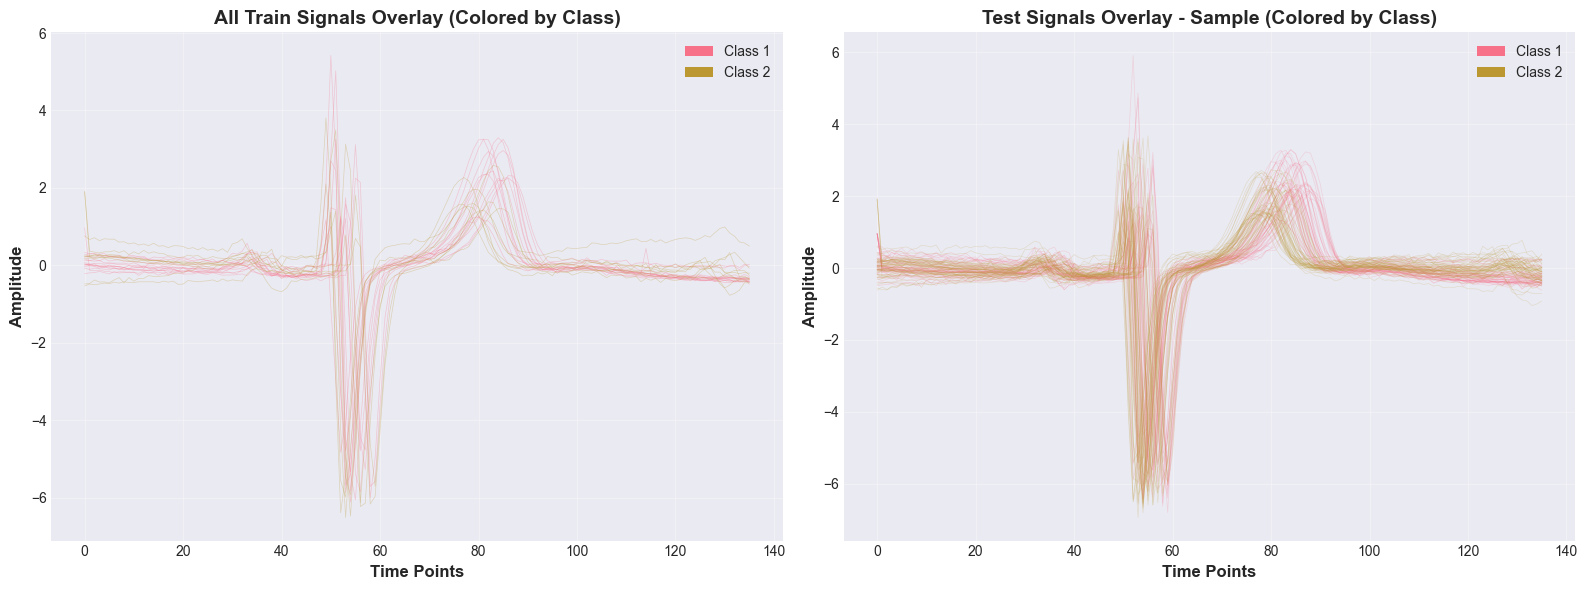


💡 Insight: Perhatikan overlap antar kelas - semakin besar overlap, semakin challenging klasifikasinya


In [24]:
# Plot all signals colored by class for visual separability check
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train set
for cls in classes:
    class_samples = X_train[y_train == cls]
    for sample in class_samples:
        axes[0].plot(sample, alpha=0.3, linewidth=0.5, color=f'C{cls-1}')

axes[0].set_xlabel('Time Points', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude', fontsize=12, fontweight='bold')
axes[0].set_title('All Train Signals Overlay (Colored by Class)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=f'C{i}', label=f'Class {cls}') 
                   for i, cls in enumerate(classes)]
axes[0].legend(handles=legend_elements)

# Test set
for cls in classes:
    class_samples = X_test[y_test == cls]
    # Plot only subset for visibility
    subset_size = min(50, len(class_samples))
    subset_indices = np.random.choice(len(class_samples), subset_size, replace=False)
    for idx in subset_indices:
        axes[1].plot(class_samples[idx], alpha=0.2, linewidth=0.5, color=f'C{cls-1}')

axes[1].set_xlabel('Time Points', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude', fontsize=12, fontweight='bold')
axes[1].set_title('Test Signals Overlay - Sample (Colored by Class)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print("\n💡 Insight: Perhatikan overlap antar kelas - semakin besar overlap, semakin challenging klasifikasinya")


### 16. Save Processed Insights

In [26]:
# Save key statistics for later use
insights = {
    'n_train': X_train.shape[0],
    'n_test': X_test.shape[0],
    'n_timepoints': X_train.shape[1],
    'n_classes': len(classes),
    'classes': classes.tolist(),
    'train_class_distribution': train_counts.to_dict(),
    'test_class_distribution': test_counts.to_dict(),
    'value_range': [float(X_train.min()), float(X_train.max())],
    'mean': float(np.mean(X_train)),
    'std': float(np.std(X_train)),
    'missing_values': int(train_missing),
    'outlier_percentage': float(pct_outliers_train)
}

# Save to numpy for easy loading
np.save('eda_insights.npy', insights)
print("\n✓ EDA insights saved to 'eda_insights.npy'")


✓ EDA insights saved to 'eda_insights.npy'
